In [79]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from app.data_providers import test_train_dataset
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer

from sklearn.pipeline import FeatureUnion
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.inspection import permutation_importance

from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

import logging

import joblib

pd.set_option('display.max_columns', None)

# Import data

In [2]:
data = test_train_dataset()

Repo card metadata block was not found. Setting CardData to empty.


In [38]:
X_train = data['train'].drop('SHOT_MADE_FLAG', axis=1)
y_train = data['train']['SHOT_MADE_FLAG']

X_test = data['test'].drop('SHOT_MADE_FLAG', axis=1)
y_test = data['test']['SHOT_MADE_FLAG']

# Additional features and drop irrelevant features

In [39]:
cols_2_drop = ['GAME_ID_x', 'GAME_EVENT_ID', 'SHOT_TYPE', 'HTM', 'VTM', 'GAME_DATE', 'TEAM_ID', 'shotResult', 
               'MINUTES_REMAINING', 'SECONDS_REMAINING', 'clock', 'PLAYER_ID',
              'PLAYER2_ID', 'PLAYER2_NAME', 'PLAYER2_TEAM_ABBREVIATION', 'PLAYER3_ID', 'PLAYER3_NAME', 'PCTIMESTRING',
              'pointsHome', 'pointsAway', 'scoreHome', 'scoreAway', 'scoreMargin', '__index_level_0__']

In [40]:
cols_OneHot = ['SHOT_ZONE_RANGE', 'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'PLAYER_NAME', 'is_playoffs', 'OPPONENT_INTERFERED', 'MAIN_ACTION_TYPE']
cols_targetEncode = ['ACTION_TYPE', 'PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']

In [41]:
X_train.head(2)

,GAME_ID_x,GAME_EVENT_ID,SHOT_TYPE,SHOT_DISTANCE,SHOT_ZONE_RANGE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,LOC_X,LOC_Y,ACTION_TYPE,HTM,VTM,GAME_DATE,TEAM_ID,PLAYER1_TEAM_ABBREVIATION,PLAYER_ID,scoreHome,scoreAway,shotResult,MINUTES_REMAINING,SECONDS_REMAINING,clock,PLAYER_NAME,PERIOD_x,PLAYER2_ID,PLAYER2_NAME,PLAYER2_TEAM_ABBREVIATION,PLAYER3_ID,PLAYER3_NAME,is_playoffs,PCTIMESTRING,IS_HOME,points,pointsHome,pointsAway,scoreHomeBeforeShot,scoreAwayBeforeShot,scoreMargin,scoreMarginBeforeShot,TimeRemainingInPeriod,TotalPlayedTime,TimeRemainingInGame,IsOvertime,OvertimeNumber,IsClutchTime,OPPONENT_INTERFERED,ANGLE,ANGLE_SECTOR,ABS_ANGLE,ANGLE_SIN,ANGLE_COS,MAIN_ACTION_TYPE,__index_level_0__
0,29600008.0,281.0,2PT Field Goal,8.0,8-16 ft.,In The Paint (Non-RA),Left Side(L),-42.0,69.0,Jump Shot,MIN,SAS,19961101.0,1.610613e+09,MIN,708.0,50,44,Missed,5.0,25.0,PT05M25.00S,Kevin Garnett,3.0,0.0,NaN,NaN,0.0,NaN,False,5:25,1,2,0,0,50.0,44.0,6,6.0,325,1835,1045,0,0,0,False,-31.328693,0,31.328693,0.087123,0.996198,Jump,448756
1,29600008.0,168.0,1PT Free Throw,15.0,8-16 ft.,Mid-Range,Center(C),0.0,15.0,Free Throw,MIN,SAS,19961101.0,1.610613e+09,MIN,708.0,27,31,Missed,6.0,31.0,PT06M31.00S,Kevin Garnett,2.0,0.0,NaN,NaN,0.0,NaN,False,6:31,1,1,0,0,27.0,31.0,-4,-4.0,391,1049,1831,0,0,0,False,0.000000,0,0.000000,0.000000,1.000000,Other,448749


In [70]:
def add_additional_features(df_): 
    if not pd.api.types.is_datetime64_any_dtype(df_['GAME_DATE']):

        df_['GAME_DATE'] = pd.to_datetime(
            df_['GAME_DATE'].astype(str),
            format='%Y%m%d',
            errors='coerce'
        )
    df_['year'] = df_['GAME_DATE'].dt.year
    df_['month'] = df_['GAME_DATE'].dt.month
    df_['day'] = df_['GAME_DATE'].dt.weekday

    df_['Opponent_team_abbreviation'] = df_['HTM']
    df_.loc[X_train['IS_HOME'] == 0, 'Opponent_team_abbreviation'] = df_.loc[df_['IS_HOME'] == 0, 'VTM']

    return df_

In [43]:
X_train = add_additional_features(X_train)
X_test = add_additional_features(X_test)

In [44]:
X_train = X_train.drop(cols_2_drop, axis=1)
X_test = X_test.drop(cols_2_drop, axis=1)

In [10]:
X_train.head()

,SHOT_DISTANCE,SHOT_ZONE_RANGE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,LOC_X,LOC_Y,ACTION_TYPE,PLAYER1_TEAM_ABBREVIATION,PLAYER_NAME,PERIOD_x,is_playoffs,IS_HOME,points,scoreHomeBeforeShot,scoreAwayBeforeShot,scoreMarginBeforeShot,TimeRemainingInPeriod,TotalPlayedTime,TimeRemainingInGame,IsOvertime,OvertimeNumber,IsClutchTime,OPPONENT_INTERFERED,ANGLE,ANGLE_SECTOR,ABS_ANGLE,ANGLE_SIN,ANGLE_COS,MAIN_ACTION_TYPE,year,month,day,Opponent_team_abbreviation
0,8.0,8-16 ft.,In The Paint (Non-RA),Left Side(L),-42.0,69.0,Jump Shot,MIN,Kevin Garnett,3.0,False,1,2,50.0,44.0,6.0,325,1835,1045,0,0,0,False,-31.328693,0,31.328693,0.087123,0.996198,Jump,1996,11,4,MIN
1,15.0,8-16 ft.,Mid-Range,Center(C),0.0,15.0,Free Throw,MIN,Kevin Garnett,2.0,False,1,1,27.0,31.0,-4.0,391,1049,1831,0,0,0,False,0.000000,0,0.000000,0.000000,1.000000,Other,1996,11,4,MIN
2,12.0,8-16 ft.,Mid-Range,Right Side(R),112.0,58.0,Jump Shot,MIN,Kevin Garnett,4.0,False,1,2,71.0,70.0,1.0,173,2707,173,0,0,1,False,62.622297,1,62.622297,-0.208025,0.978123,Jump,1996,11,4,MIN
3,14.0,8-16 ft.,Mid-Range,Right Side(R),140.0,-5.0,Jump Shot,MIN,Kevin Garnett,2.0,False,1,2,35.0,34.0,1.0,193,1247,1633,0,0,0,False,92.045408,2,92.045408,-0.807099,-0.590417,Jump,1996,11,4,MIN
4,16.0,16-24 ft.,Mid-Range,Right Side(R),151.0,67.0,Jump Shot,MIN,Kevin Garnett,3.0,False,1,2,48.0,42.0,6.0,465,1695,1185,0,0,0,False,66.072727,1,66.072727,-0.099118,-0.995076,Jump,1996,11,4,MIN


# Recursive Feature Elimination

### Encoding and scaling

In [11]:
numerical_cols = ['SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'scoreHomeBeforeShot', 'scoreAwayBeforeShot', 'scoreMarginBeforeShot', 'TimeRemainingInPeriod', 'TotalPlayedTime',
                 'TimeRemainingInGame', 'ANGLE', 'ABS_ANGLE', 'ANGLE_SIN', 'ANGLE_COS', 'year', 'month', 'day', 'points', 'PERIOD_x']

# One hot encoding
encoder_oh = OneHotEncoder(sparse_output=False, drop='first', handle_unknown="ignore")
encoder_target = TargetEncoder()
scaler = StandardScaler()

column_encoder = make_column_transformer(
    (encoder_oh, cols_OneHot),
    (encoder_target, cols_targetEncode),
    (scaler, numerical_cols),
    remainder='passthrough',
    verbose_feature_names_out=False
)
column_encoder.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('targetencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_nam

In [36]:
X_train_enc = column_encoder.fit_transform(X_train, y_train)
X_test_enc = column_encoder.transform(X_train, y_train)

### Train recursive feature elimination with logistic regression

In [41]:
logging.basicConfig(level=logging.INFO)

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000),
    step=1,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

X_train_sel = rfecv.fit_transform(X_train_enc, y_train)

selected_features = X_train_enc.columns[rfecv.support_]

Fitting estimator with 73 features.
Fitting estimator with 72 features.
Fitting estimator with 71 features.
Fitting estimator with 70 features.
Fitting estimator with 69 features.
Fitting estimator with 68 features.
Fitting estimator with 67 features.
Fitting estimator with 66 features.
Fitting estimator with 65 features.
Fitting estimator with 64 features.
Fitting estimator with 63 features.
Fitting estimator with 62 features.
Fitting estimator with 61 features.
Fitting estimator with 60 features.
Fitting estimator with 59 features.
Fitting estimator with 58 features.
Fitting estimator with 57 features.
Fitting estimator with 56 features.
Fitting estimator with 55 features.


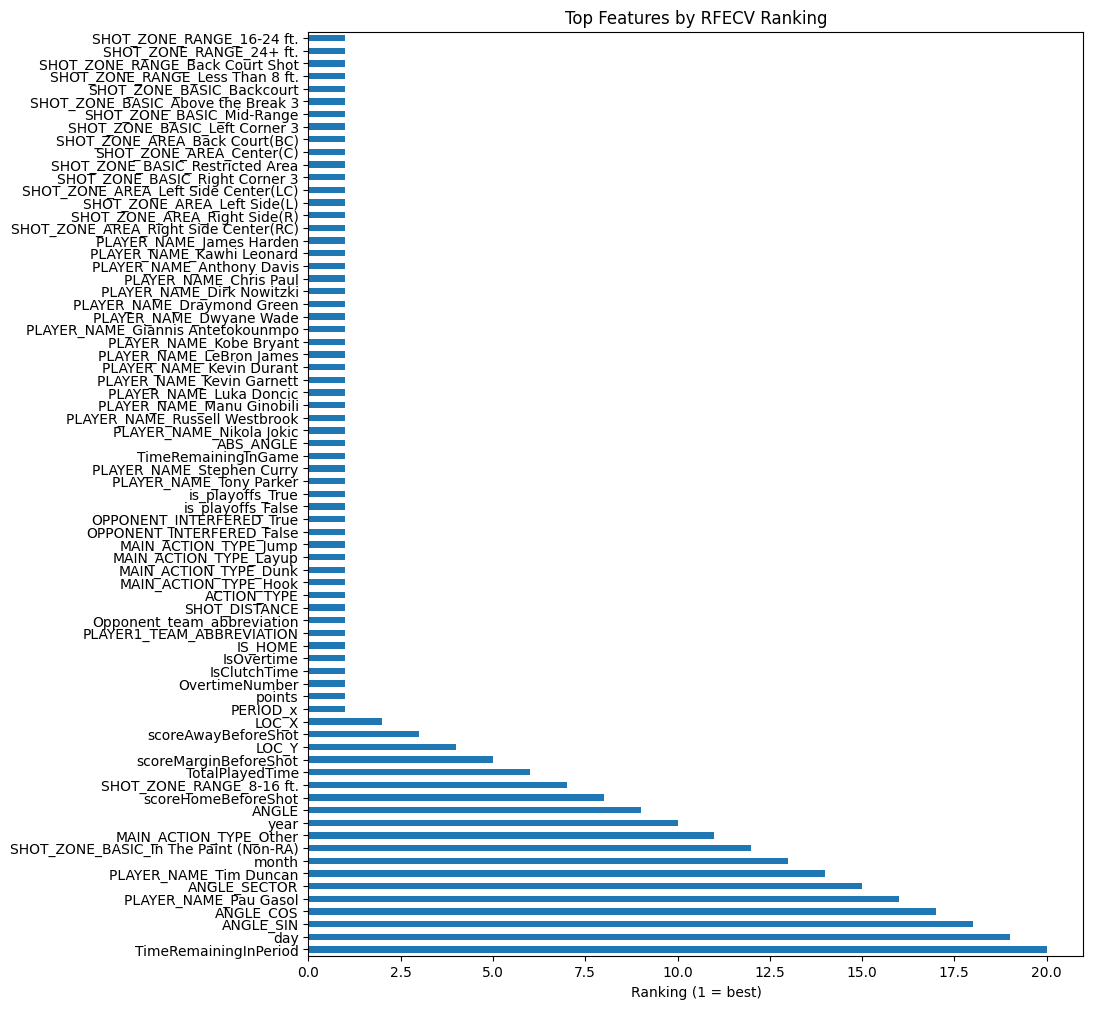

In [49]:
ranking = pd.Series(rfecv.ranking_, index=X_train_enc.columns)

ranking = ranking.sort_values()  # best first

plt.figure(figsize=(10, 12))
ranking.plot(kind="barh")  # show top 30
plt.gca().invert_yaxis()
plt.title("Top Features by RFECV Ranking")
plt.xlabel("Ranking (1 = best)")
plt.show()

In [51]:
selected = X_train_enc.columns[rfecv.support_]
rejected = X_train_enc.columns[~rfecv.support_]

print("Selected features: ", selected)
print("Rejected features: ", rejected)

Selected features:  Index(['SHOT_ZONE_RANGE_16-24 ft.', 'SHOT_ZONE_RANGE_24+ ft.',
       'SHOT_ZONE_RANGE_Back Court Shot', 'SHOT_ZONE_RANGE_Less Than 8 ft.',
       'SHOT_ZONE_BASIC_Above the Break 3', 'SHOT_ZONE_BASIC_Backcourt',
       'SHOT_ZONE_BASIC_Left Corner 3', 'SHOT_ZONE_BASIC_Mid-Range',
       'SHOT_ZONE_BASIC_Restricted Area', 'SHOT_ZONE_BASIC_Right Corner 3',
       'SHOT_ZONE_AREA_Back Court(BC)', 'SHOT_ZONE_AREA_Center(C)',
       'SHOT_ZONE_AREA_Left Side Center(LC)', 'SHOT_ZONE_AREA_Left Side(L)',
       'SHOT_ZONE_AREA_Right Side Center(RC)', 'SHOT_ZONE_AREA_Right Side(R)',
       'PLAYER_NAME_Anthony Davis', 'PLAYER_NAME_Chris Paul',
       'PLAYER_NAME_Dirk Nowitzki', 'PLAYER_NAME_Draymond Green',
       'PLAYER_NAME_Dwyane Wade', 'PLAYER_NAME_Giannis Antetokounmpo',
       'PLAYER_NAME_James Harden', 'PLAYER_NAME_Kawhi Leonard',
       'PLAYER_NAME_Kevin Durant', 'PLAYER_NAME_Kevin Garnett',
       'PLAYER_NAME_Kobe Bryant', 'PLAYER_NAME_LeBron James',
       'P

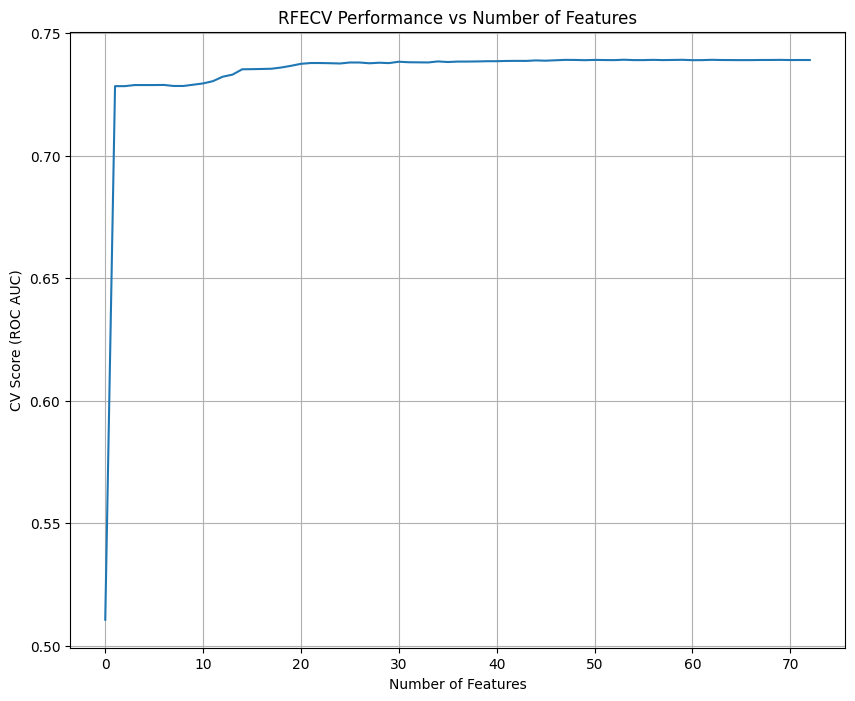

In [55]:
plt.figure(figsize=(10,8))
plt.plot(rfecv.cv_results_["mean_test_score"])
plt.xlabel("Number of Features")
plt.ylabel("CV Score (ROC AUC)")
plt.title("RFECV Performance vs Number of Features")
plt.grid()
plt.show()

In [60]:
ranking_df = pd.DataFrame({
    "feature": X_train_enc.columns,
    "rank": rfecv.ranking_
})

ranking_df["original_feature"] = ranking_df["feature"].str.split("_").str[0]
ranking_df.head(20)

,feature,rank,original_feature
0,SHOT_ZONE_RANGE_16-24 ft.,1,SHOT
1,SHOT_ZONE_RANGE_24+ ft.,1,SHOT
2,SHOT_ZONE_RANGE_8-16 ft.,7,SHOT
3,SHOT_ZONE_RANGE_Back Court Shot,1,SHOT
4,SHOT_ZONE_RANGE_Less Than 8 ft.,1,SHOT
5,SHOT_ZONE_BASIC_Above the Break 3,1,SHOT
6,SHOT_ZONE_BASIC_Backcourt,1,SHOT
7,SHOT_ZONE_BASIC_In The Paint (Non-RA),12,SHOT
8,SHOT_ZONE_BASIC_Left Corner 3,1,SHOT
9,SHOT_ZONE_BASIC_Mid-Range,1,SHOT


# Gradient Boosting classifier

### Encoding and training

In [24]:
# No standardisation needed here

column_encoder = make_column_transformer(
    (encoder_oh, cols_OneHot),
    (encoder_target, cols_targetEncode),
    remainder='passthrough',
    verbose_feature_names_out=False
)
column_encoder.set_output(transform="pandas")

X_train_enc = column_encoder.fit_transform(X_train, y_train)
X_test_enc = column_encoder.transform(X_test)

In [25]:
model_grad = GradientBoostingClassifier(random_state=42, verbose=2)
model_grad.fit(X_train_enc, y_train)

      Iter       Train Loss   Remaining Time 
         1           1.3358            3.40m
         2           1.3099            3.52m
         3           1.2887            3.51m
         4           1.2712            3.50m
         5           1.2568            3.47m
         6           1.2448            3.44m
         7           1.2347            3.41m
         8           1.2265            3.37m
         9           1.2196            3.32m
        10           1.2137            3.28m
        11           1.2089            3.24m
        12           1.2046            3.22m
        13           1.2012            3.18m
        14           1.1981            3.14m
        15           1.1953            3.09m
        16           1.1930            3.04m
        17           1.1910            3.01m
        18           1.1893            2.95m
        19           1.1878            2.92m
        20           1.1866            2.88m
        21           1.1854            2.85m
        2

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

### Check results

<BarContainer object of 20 artists>

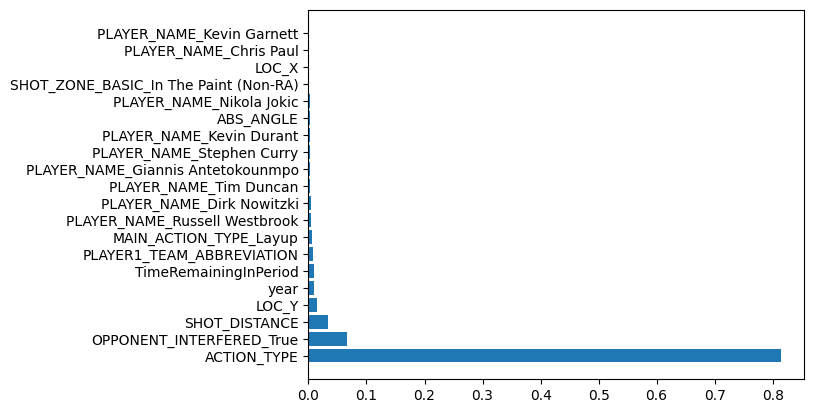

In [26]:
feat_imp = pd.Series(
    model_grad.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

plt.barh(feat_imp.head(20).index, feat_imp.head(20).values)

In [27]:
y_pred = model_grad.predict(X_test_enc)
y_pred_proba = model_grad.predict_proba(X_test_enc)

In [28]:
print(roc_auc_score(y_test, y_pred_proba[:,1]))

0.747804223118544


In [29]:
pd.crosstab(y_test, y_pred)

col_0,0.0,1.0
SHOT_MADE_FLAG,,
0.0,31754,14683
1.0,18832,42413


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.63      0.68      0.65     46437
         1.0       0.74      0.69      0.72     61245

    accuracy                           0.69    107682
   macro avg       0.69      0.69      0.69    107682
weighted avg       0.69      0.69      0.69    107682



In [31]:
perm = permutation_importance(
    model_grad,
    X_test_enc, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(
    perm.importances_mean,
    index=X_test_enc.columns
).sort_values(ascending=False)

<BarContainer object of 30 artists>

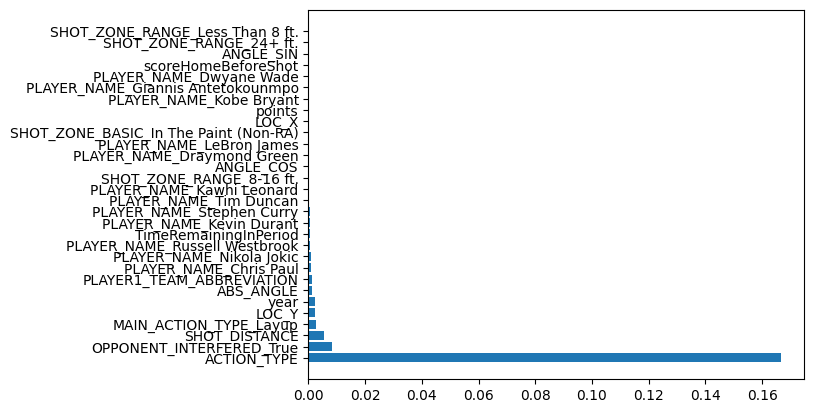

In [32]:
plt.barh(perm_imp.head(30).index, perm_imp.head(30).values)

# Test with xgboost

## Initial test

In [12]:
from xgboost import XGBClassifier

In [14]:
# No standardisation needed here

column_encoder = make_column_transformer(
    (encoder_oh, cols_OneHot),
    (encoder_target, cols_targetEncode),
    remainder='passthrough',
    verbose_feature_names_out=False
)
column_encoder.set_output(transform="pandas")

X_train_enc = column_encoder.fit_transform(X_train, y_train)
X_test_enc = column_encoder.transform(X_test)

In [16]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=2
)

model.fit(X_train_enc, y_train)

[11:59:26] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (430227, 66, 28394982).


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [21]:
y_pred_proba = model.predict_proba(X_test_enc)
y_pred = model.predict(X_test_enc)

In [23]:
print(roc_auc_score(y_test, y_pred_proba[:,1]))

display(pd.crosstab(y_test, y_pred))

print(classification_report(y_test, y_pred))

0.7525706711252067


col_0,0,1
SHOT_MADE_FLAG,,
0.0,32068,14369
1.0,18718,42527


              precision    recall  f1-score   support

         0.0       0.63      0.69      0.66     46437
         1.0       0.75      0.69      0.72     61245

    accuracy                           0.69    107682
   macro avg       0.69      0.69      0.69    107682
weighted avg       0.70      0.69      0.69    107682



<BarContainer object of 30 artists>

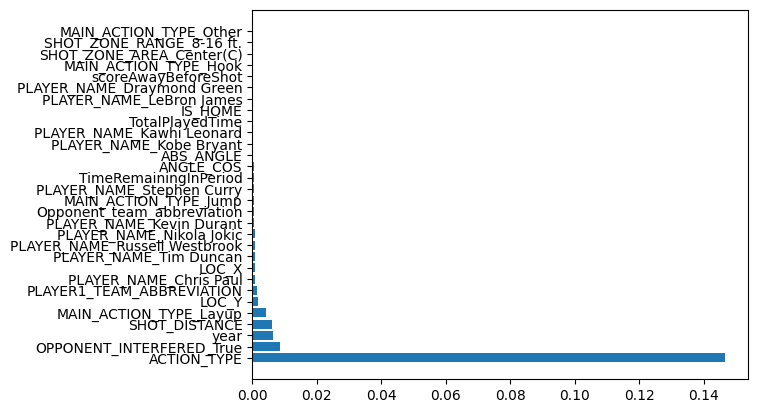

In [20]:
perm = permutation_importance(
    model,
    X_test_enc, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(
    perm.importances_mean,
    index=X_test_enc.columns
).sort_values(ascending=False)

plt.barh(perm_imp.head(30).index, perm_imp.head(30).values)

## Try with only most important features

In [33]:
feat_imp = pd.Series(
    model.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

top_30_features = feat_imp.head(30).index

X_train_top30 = X_train_enc[top_30_features]
X_test_top30   = X_test_enc[top_30_features]

In [36]:
model_top30 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_top30.fit(X_train_top30, y_train)

y_pred_top30 = model_top30.predict(X_test_top30)
y_pred_proba_top30 = model_top30.predict_proba(X_test_top30)
auc_top30 = roc_auc_score(y_test, y_pred_proba_top30[:, 1])


In [37]:
print(roc_auc_score(y_test, y_pred_proba_top30[:,1]))

display(pd.crosstab(y_test, y_pred_top30))

print(classification_report(y_test, y_pred_top30))

0.7527807324276898


col_0,0,1
SHOT_MADE_FLAG,,
0.0,31844,14593
1.0,18504,42741


              precision    recall  f1-score   support

         0.0       0.63      0.69      0.66     46437
         1.0       0.75      0.70      0.72     61245

    accuracy                           0.69    107682
   macro avg       0.69      0.69      0.69    107682
weighted avg       0.70      0.69      0.69    107682



By only taking the top 30 features, we got the same metrics, as with all features

## Feature Ablation curve

In [47]:
ranked_features = feat_imp.index

results_score = []
results_auc = []

feature_steps = list(range(1, len(ranked_features)+1))

for k in feature_steps:
    selected_features = ranked_features[:k]
    
    X_train_k = X_train_enc[selected_features]
    X_test_k   = X_test_enc[selected_features]
    
    model_k = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    model_k.fit(X_train_k, y_train)
    
    y_pred = model_k.predict_proba(X_test_k)[:, 1]
    auc = roc_auc_score(y_test, y_pred)

    score = model_k.score(X_test_k, y_test)

    results_score.append((k, score))
    results_auc.append((k, auc))
    
    print(f"{k} features, AUC: {auc:.4f},  Score: {score:.4f}")

1 features, AUC: 0.6630,  Score: 0.6626
2 features, AUC: 0.7169,  Score: 0.6686
3 features, AUC: 0.7261,  Score: 0.6763
4 features, AUC: 0.7285,  Score: 0.6789
5 features, AUC: 0.7285,  Score: 0.6789
6 features, AUC: 0.7299,  Score: 0.6786
7 features, AUC: 0.7315,  Score: 0.6796
8 features, AUC: 0.7334,  Score: 0.6816
9 features, AUC: 0.7403,  Score: 0.6840
10 features, AUC: 0.7404,  Score: 0.6844
11 features, AUC: 0.7415,  Score: 0.6854
12 features, AUC: 0.7426,  Score: 0.6870
13 features, AUC: 0.7439,  Score: 0.6879
14 features, AUC: 0.7446,  Score: 0.6878
15 features, AUC: 0.7451,  Score: 0.6885
16 features, AUC: 0.7460,  Score: 0.6894
17 features, AUC: 0.7460,  Score: 0.6892
18 features, AUC: 0.7465,  Score: 0.6892
19 features, AUC: 0.7471,  Score: 0.6897
20 features, AUC: 0.7472,  Score: 0.6897
21 features, AUC: 0.7496,  Score: 0.6912
22 features, AUC: 0.7501,  Score: 0.6913
23 features, AUC: 0.7502,  Score: 0.6905
24 features, AUC: 0.7520,  Score: 0.6918
25 features, AUC: 0.7521,

In [80]:
results_df = pd.DataFrame(results_auc, columns=["n_features", "auc"])
results_df = pd.concat([results_df, pd.DataFrame(results_score, columns=["n_features", "score"]).drop('n_features', axis=1)], axis=1)

results_df['auc_diff'] = results_df['auc'].diff()
#results_df.loc[0, 'auc_diff'] = results_df['auc'].loc[0]

results_df['score_diff'] = results_df['score'].diff()
#results_df.loc[0, 'score_diff'] = results_df['score'].loc[0]

results_df['feature_added'] = ranked_features

results_df.head(25)


,n_features,auc,score,auc_diff,score_diff,feature_added
0,1,0.662980,0.662618,NaN,NaN,MAIN_ACTION_TYPE_Jump
1,2,0.716872,0.668570,0.053892,0.005953,ACTION_TYPE
2,3,0.726089,0.676250,0.009218,0.007680,OPPONENT_INTERFERED_True
3,4,0.728516,0.678925,0.002427,0.002675,points
4,5,0.728482,0.678925,-0.000034,0.000000,MAIN_ACTION_TYPE_Layup
5,6,0.729877,0.678563,0.001395,-0.000362,PLAYER_NAME_Giannis Antetokounmpo
6,7,0.731549,0.679584,0.001672,0.001022,PLAYER_NAME_Dirk Nowitzki
7,8,0.733430,0.681646,0.001881,0.002062,PLAYER_NAME_Tim Duncan
8,9,0.740296,0.684033,0.006866,0.002387,SHOT_DISTANCE
9,10,0.740418,0.684404,0.000122,0.000371,MAIN_ACTION_TYPE_Other


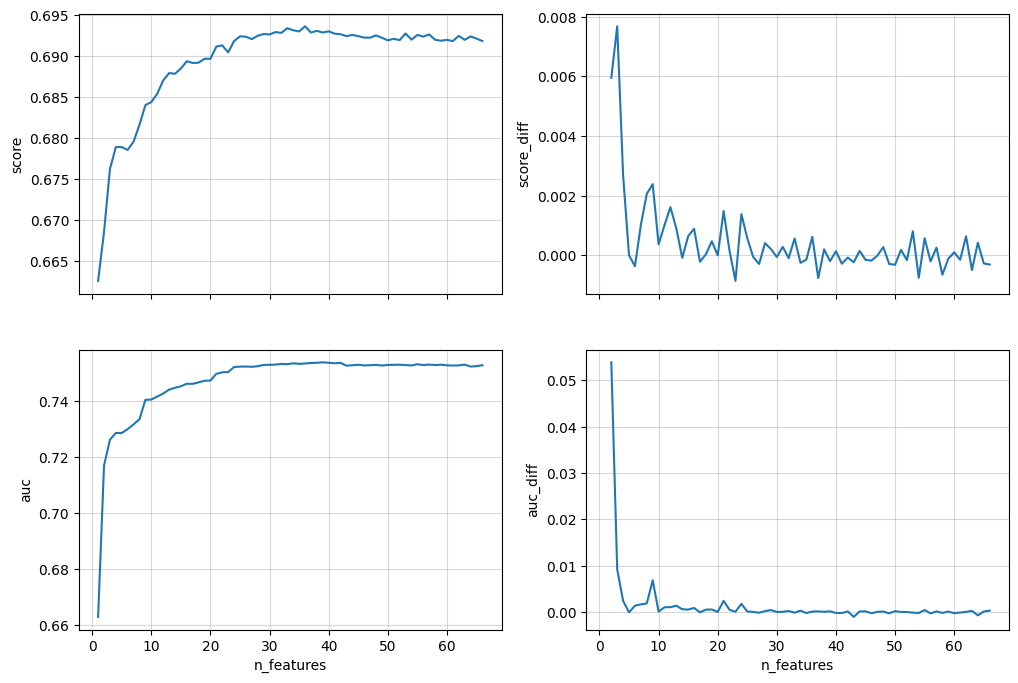

In [77]:
fig, axs = plt.subplots(2, 2, figsize=(12,8), sharex=True)

sns.lineplot(data=results_df, x='n_features', y='score', ax=axs[0,0])
axs[0,0].grid(alpha=0.5)

sns.lineplot(data=results_df, x='n_features', y='score_diff', ax=axs[0,1])
axs[0,1].grid(alpha=0.5)

sns.lineplot(data=results_df, x='n_features', y='auc', ax=axs[1,0])
axs[1,0].grid(alpha=0.5)

sns.lineplot(data=results_df, x='n_features', y='auc_diff', ax=axs[1,1])
axs[1,1].grid(alpha=0.5)

plt.show()

We reach the highest score after about 35 features. But already after 15 features the accuracy impact is starting to decrease

In [67]:
ranked_features[:35]

Index(['MAIN_ACTION_TYPE_Jump', 'ACTION_TYPE', 'OPPONENT_INTERFERED_True',
       'points', 'MAIN_ACTION_TYPE_Layup', 'PLAYER_NAME_Giannis Antetokounmpo',
       'PLAYER_NAME_Dirk Nowitzki', 'PLAYER_NAME_Tim Duncan', 'SHOT_DISTANCE',
       'MAIN_ACTION_TYPE_Other', 'PLAYER_NAME_Stephen Curry', 'LOC_Y',
       'PLAYER_NAME_Kevin Durant', 'PLAYER_NAME_James Harden',
       'PLAYER_NAME_Nikola Jokic', 'PLAYER_NAME_Kobe Bryant',
       'SHOT_ZONE_RANGE_Less Than 8 ft.', 'PLAYER_NAME_Chris Paul',
       'PLAYER_NAME_LeBron James', 'SHOT_ZONE_BASIC_Restricted Area',
       'PLAYER1_TEAM_ABBREVIATION', 'PLAYER_NAME_Russell Westbrook',
       'PLAYER_NAME_Kevin Garnett', 'year', 'SHOT_ZONE_BASIC_Mid-Range',
       'PLAYER_NAME_Draymond Green', 'SHOT_ZONE_BASIC_In The Paint (Non-RA)',
       'ANGLE_SECTOR', 'TimeRemainingInPeriod', 'MAIN_ACTION_TYPE_Hook',
       'SHOT_ZONE_RANGE_Back Court Shot', 'PLAYER_NAME_Kawhi Leonard',
       'SHOT_ZONE_AREA_Center(C)', 'IS_HOME', 'SHOT_ZONE_RANGE_8-16 

# Random search for hyperparameters

In [81]:
from sklearn.model_selection import RandomizedSearchCV

In [82]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2],
    "min_child_weight": [1, 3, 5]
}

xgb = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100,            
    scoring="roc_auc",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train_enc, y_train)

best_model = search.best_estimator_

print("Best params:", search.best_params_)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.9}


In [83]:
# Save results
import joblib

joblib.dump(search, "xgb_random_search.pkl")

['xgb_random_search.pkl']

## Evaluate performance of best model

In [84]:
y_pred_search = best_model.predict(X_test_enc)
y_pred_proba_search = best_model.predict_proba(X_test_enc)

print(roc_auc_score(y_test, y_pred_proba_search[:,1]))
display(pd.crosstab(y_test, y_pred_search))
print(classification_report(y_test, y_pred_search))

0.751217296688744


col_0,0,1
SHOT_MADE_FLAG,,
0.0,31807,14630
1.0,18623,42622


              precision    recall  f1-score   support

         0.0       0.63      0.68      0.66     46437
         1.0       0.74      0.70      0.72     61245

    accuracy                           0.69    107682
   macro avg       0.69      0.69      0.69    107682
weighted avg       0.70      0.69      0.69    107682



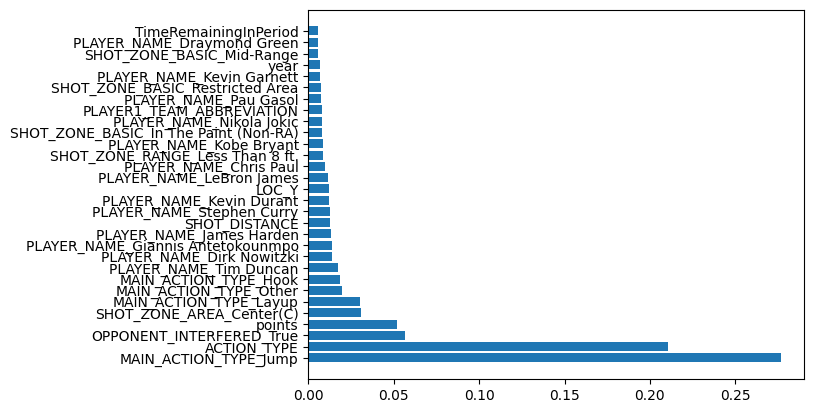

In [88]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

plt.barh(feat_imp.head(30).index, feat_imp.head(30).values);

# Action type test

<BarContainer object of 30 artists>

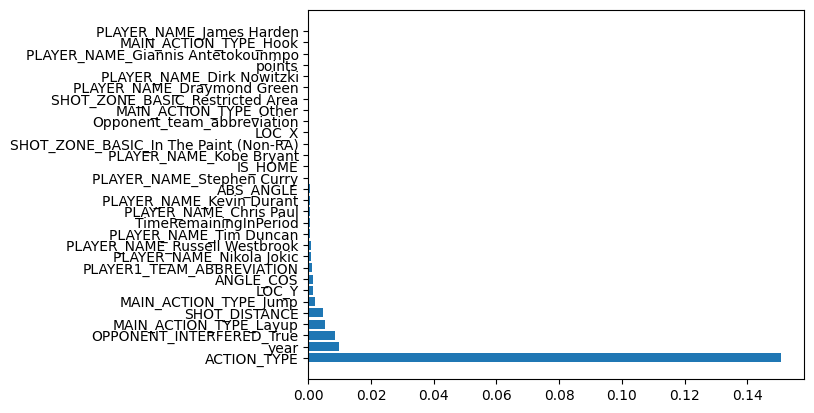

In [89]:
perm = permutation_importance(
    best_model,
    X_test_enc, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(
    perm.importances_mean,
    index=X_test_enc.columns
).sort_values(ascending=False)

plt.barh(perm_imp.head(30).index, perm_imp.head(30).values)

In [90]:
X_test_shuffled = X_test_enc.copy()
X_test_shuffled["ACTION_TYPE"] = np.random.permutation(X_test_shuffled["ACTION_TYPE"])

y_pred_shuffled = model.predict_proba(X_test_shuffled)

print(roc_auc_score(y_test, y_pred_shuffled[:,1]))

0.5700801477565987


The test with permutation importance and random shuffling of action type shows, that the model heavily relies on action_type

# Grid search for encoding strategy for action type

In [144]:
from sklearn.base import BaseEstimator, TransformerMixin
from category_encoders import BinaryEncoder
from category_encoders.leave_one_out import LeaveOneOutEncoder
from category_encoders.james_stein import JamesSteinEncoder

from sklearn.model_selection import GridSearchCV

In [145]:
cols_targetEncode

['ACTION_TYPE', 'PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']

In [146]:
cols_targetEncode_new = ['PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']

def make_preprocessor(action_encoder):
    return make_column_transformer(
        (action_encoder, ["ACTION_TYPE"]),
        (encoder_oh, cols_OneHot),
        (encoder_target, cols_targetEncode_new),
        remainder="passthrough",
        verbose_feature_names_out=False
    )

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.freq = X.iloc[:, 0].value_counts(normalize=True)
        return self
    
    def transform(self, X):
        return X.iloc[:, 0].map(self.freq).fillna(0).to_frame()


class ProbabilityRatioEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=1.0):
        self.smoothing = smoothing

    def fit(self, X, y):
        X = pd.DataFrame(X)
        y = pd.Series(y)

        self.global_pos = y.mean()
        self.global_neg = 1 - self.global_pos

        df = pd.concat([X, y], axis=1)
        df.columns = ["cat", "target"]

        stats = df.groupby("cat")["target"].agg(["sum", "count"])
        stats["neg"] = stats["count"] - stats["sum"]

        # smoothing
        stats["pos_smooth"] = stats["sum"] + self.smoothing * self.global_pos
        stats["neg_smooth"] = stats["neg"] + self.smoothing * self.global_neg

        stats["ratio"] = stats["pos_smooth"] / stats["neg_smooth"]

        self.mapping_ = stats["ratio"]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        encoded = X.iloc[:, 0].map(self.mapping_)

        # fallback to global ratio
        default = self.global_pos / self.global_neg
        return encoded.fillna(default).to_frame()

target_enc = TargetEncoder()
loo_enc = LeaveOneOutEncoder()
onehot_enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='first')
freq_enc = FrequencyEncoder()
binary_enc = BinaryEncoder()
probRatio_enc = ProbabilityRatioEncoder()
james_stein_enc = JamesSteinEncoder()

In [147]:
#{'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.9}
pipe = Pipeline([
    ("preprocessor", make_preprocessor(encoder_target)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.01,
        subsample=0.7,
        colsample_bytree=0.9,
        min_child_weight=3,
        gamma=0.2,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

In [148]:
param_grid = {
    "preprocessor": [
        make_preprocessor(target_enc),
        make_preprocessor(loo_enc),
        make_preprocessor(onehot_enc),
        make_preprocessor(freq_enc),
        make_preprocessor(binary_enc),
        make_preprocessor(james_stein_enc),
        make_preprocessor(probRatio_enc),
    ]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best AUC:", grid.best_score_)

Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best params: {'preprocessor': ColumnTransformer(remainder='passthrough',
                  transformers=[('frequencyencoder', FrequencyEncoder(),
                                 ['ACTION_TYPE']),
                                ('onehotencoder',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['SHOT_ZONE_RANGE', 'SHOT_ZONE_BASIC',
                                  'SHOT_ZONE_AREA', 'PLAYER_NAME',
                                  'is_playoffs', 'OPPONENT_INTERFERED',
                                  'MAIN_ACTION_TYPE']),
                                ('targetencoder', TargetEncoder(),
                                 ['PLAYER1_TEAM_ABBREVIATION',
                                  'Opponent_team_abbreviation'])],
                  verbose_f

## Try with combination of encoders

In [149]:
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer

In [166]:
def select_action(X):
    X = pd.DataFrame(X)
    return X[["ACTION_TYPE"]]

selector = FunctionTransformer(select_action)

In [167]:
action_encoder_union = FeatureUnion([
    ("target", Pipeline([
        ("select", selector),
        ("enc", target_enc)
    ])),
    ("freq", Pipeline([
        ("select", selector),
        ("enc", freq_enc)
    ])),
    #("ratio", Pipeline([
    #    ("select", selector),
    #    ("enc", probRatio_enc)
    #])),
])

In [170]:
pipe = Pipeline([
    ("preprocessor", make_column_transformer(
        (target_enc, ["ACTION_TYPE"]), 
        (freq_enc, ["ACTION_TYPE"]), 
        (probRatio_enc, ["ACTION_TYPE"]), 
        (encoder_oh, cols_OneHot),
        (encoder_target, cols_targetEncode_new),
        remainder="passthrough",
        verbose_feature_names_out=False
    )),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.01,
        subsample=0.7,
        colsample_bytree=0.9,
        min_child_weight=3,
        gamma=0.2,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('targetencoder-1', ...), ('frequencyencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [171]:
y_pred_union = pipe.predict(X_test)
y_pred_proba_union = pipe.predict_proba(X_test)

print(roc_auc_score(y_test, y_pred_proba_union[:,1]))
display(pd.crosstab(y_test, y_pred_union))
print(classification_report(y_test, y_pred_union))

0.7516956810782784


col_0,0,1
SHOT_MADE_FLAG,,
0.0,31794,14643
1.0,18587,42658


              precision    recall  f1-score   support

         0.0       0.63      0.68      0.66     46437
         1.0       0.74      0.70      0.72     61245

    accuracy                           0.69    107682
   macro avg       0.69      0.69      0.69    107682
weighted avg       0.70      0.69      0.69    107682



The metrics did not change significantly compared to the other tests with only one encoder

# Test Action type and opponent interfered for data leakage

## Train without feature

In [11]:
X_train = X_train.drop(columns=['ACTION_TYPE', 'OPPONENT_INTERFERED'], errors='ignore')
X_test = X_test.drop(columns=['ACTION_TYPE', 'OPPONENT_INTERFERED'], errors='ignore')

cols_targetEncode.remove('ACTION_TYPE')
cols_OneHot.remove('OPPONENT_INTERFERED')

In [16]:
encoder_oh = OneHotEncoder(sparse_output=False, drop='first', handle_unknown="ignore")
encoder_target = TargetEncoder()

column_encoder = make_column_transformer(
    (encoder_oh, cols_OneHot),
    (encoder_target, cols_targetEncode),
    remainder='passthrough',
    verbose_feature_names_out=False
)
column_encoder.set_output(transform="pandas")

X_train_enc = column_encoder.fit_transform(X_train, y_train)
X_test_enc = column_encoder.transform(X_test)

In [17]:
model = XGBClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.01,
        subsample=0.7,
        colsample_bytree=0.9,
        min_child_weight=3,
        gamma=0.2,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
)

model.fit(X_train_enc, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [18]:
y_pred_proba = model.predict_proba(X_test_enc)
y_pred = model.predict(X_test_enc)

print(roc_auc_score(y_test, y_pred_proba[:,1]))
display(pd.crosstab(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7229472896626504


col_0,0,1
SHOT_MADE_FLAG,,
0.0,32160,14277
1.0,21434,39811


              precision    recall  f1-score   support

         0.0       0.60      0.69      0.64     46437
         1.0       0.74      0.65      0.69     61245

    accuracy                           0.67    107682
   macro avg       0.67      0.67      0.67    107682
weighted avg       0.68      0.67      0.67    107682



<BarContainer object of 30 artists>

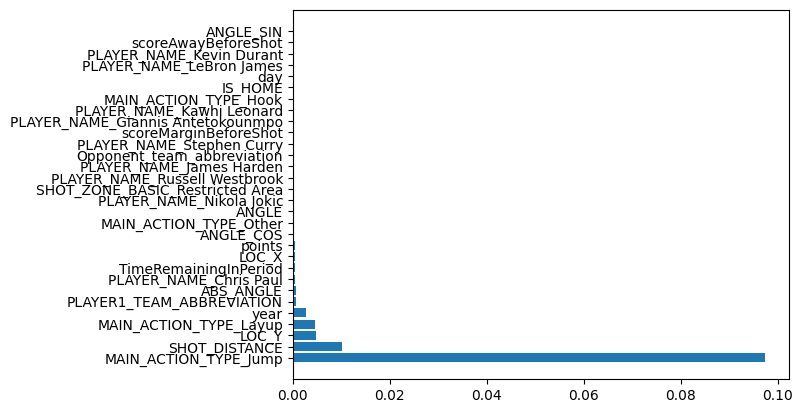

In [19]:
perm = permutation_importance(
    model,
    X_test_enc, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(
    perm.importances_mean,
    index=X_test_enc.columns
).sort_values(ascending=False)

plt.barh(perm_imp.head(30).index, perm_imp.head(30).values)

## Improved feature importance for one hot

In [52]:
from collections import defaultdict

feature_groups = defaultdict(list)

for col in X_train_enc.columns:
    matched = False
    # group one-hot encoded columns
    for base_col in cols_OneHot:
        prefix = f"{base_col}_"
        
        if col.startswith(prefix):
            feature_groups[base_col].append(col)
            matched = True
            break
            
    if not matched:
        feature_groups[col].append(col)

In [24]:
def grouped_permutation_importance(model, X, y, groups, n_repeats=5):
    baseline_score = roc_auc_score(
        y,
        model.predict_proba(X)[:, 1]
    )
    importances = {}
    
    for group_name, cols in groups.items():
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # shuffle rows jointly for the whole group
            shuffled = X_permuted[cols].sample(frac=1)
            shuffled.index = X_permuted.index
            
            X_permuted[cols] = shuffled
            permuted_score = roc_auc_score(
                y,
                model.predict_proba(X_permuted)[:, 1]
            )
            scores.append(baseline_score - permuted_score)
        importances[group_name] = np.mean(scores)
    return pd.Series(importances).sort_values(ascending=False)

In [27]:
group_importance = grouped_permutation_importance(
    model,
    X_test_enc,
    y_test,
    feature_groups,
    n_repeats=5
)

print(group_importance.head(20))

MAIN_ACTION_TYPE              0.092663
SHOT_DISTANCE                 0.011479
PLAYER_NAME                   0.011470
LOC_Y                         0.011469
points                        0.008545
year                          0.002738
ABS_ANGLE                     0.001706
TimeRemainingInPeriod         0.001535
ANGLE_COS                     0.000532
PLAYER1_TEAM_ABBREVIATION     0.000474
LOC_X                         0.000457
SHOT_ZONE_BASIC               0.000291
TotalPlayedTime               0.000202
Opponent_team_abbreviation    0.000136
SHOT_ZONE_AREA                0.000126
SHOT_ZONE_RANGE               0.000100
TimeRemainingInGame           0.000097
IS_HOME                       0.000067
scoreHomeBeforeShot           0.000037
ANGLE                         0.000020
dtype: float64


In [29]:
group_importance

MAIN_ACTION_TYPE              9.266344e-02
SHOT_DISTANCE                 1.147900e-02
PLAYER_NAME                   1.146962e-02
LOC_Y                         1.146870e-02
points                        8.545062e-03
year                          2.737586e-03
ABS_ANGLE                     1.705916e-03
TimeRemainingInPeriod         1.535386e-03
ANGLE_COS                     5.323857e-04
PLAYER1_TEAM_ABBREVIATION     4.743642e-04
LOC_X                         4.568579e-04
SHOT_ZONE_BASIC               2.906833e-04
TotalPlayedTime               2.021683e-04
Opponent_team_abbreviation    1.359995e-04
SHOT_ZONE_AREA                1.258132e-04
SHOT_ZONE_RANGE               9.951182e-05
TimeRemainingInGame           9.712313e-05
IS_HOME                       6.653816e-05
scoreHomeBeforeShot           3.696837e-05
ANGLE                         1.969213e-05
ANGLE_SIN                     1.349154e-05
ANGLE_SECTOR                  6.042579e-06
month                         4.331945e-06
IsClutchTim

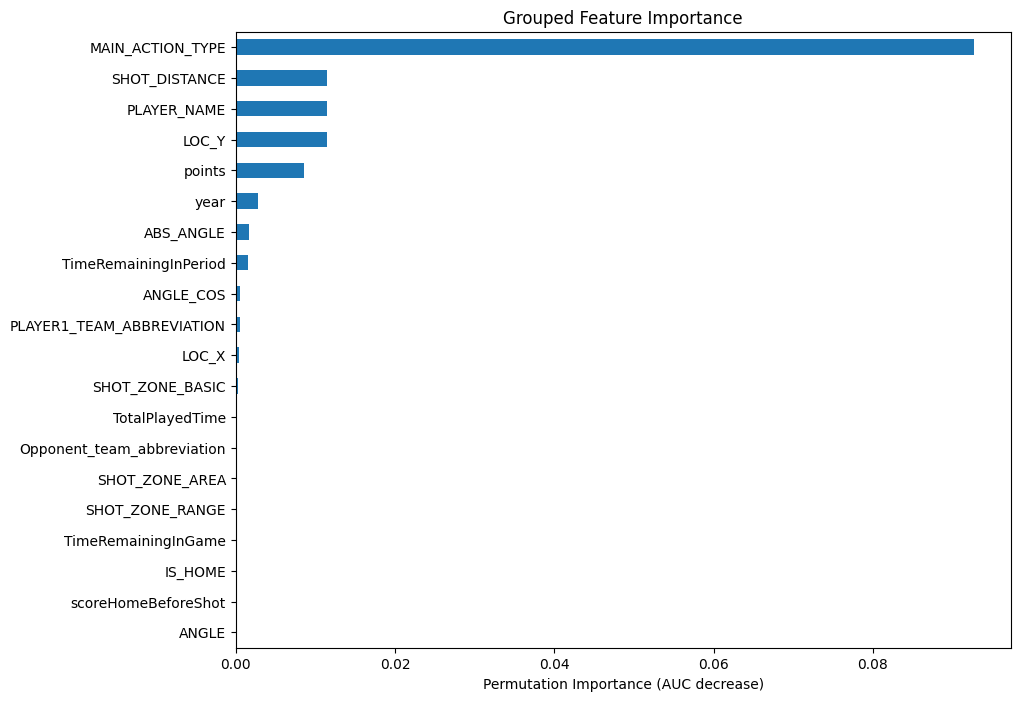

In [28]:
plt.figure(figsize=(10, 8))

group_importance.head(20).sort_values().plot(kind="barh")

plt.xlabel("Permutation Importance (AUC decrease)")
plt.title("Grouped Feature Importance")
plt.show()

## Reduce feature set based on permutation importance and build clean pipeline

In [81]:
X_train = data['train'].drop('SHOT_MADE_FLAG', axis=1)
y_train = data['train']['SHOT_MADE_FLAG']

X_test = data['test'].drop('SHOT_MADE_FLAG', axis=1)
y_test = data['test']['SHOT_MADE_FLAG']

In [82]:
cols_OneHot = ['PLAYER_NAME', 'is_playoffs', 'MAIN_ACTION_TYPE']
cols_targetEncode = ['PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']

In [83]:
def select_features(df_):
    feature_set_reduced = ['MAIN_ACTION_TYPE',
    'SHOT_DISTANCE',
    'PLAYER_NAME',
    'LOC_Y',
    'points',
    'year',
    'ABS_ANGLE',
    'TimeRemainingInPeriod',
    'PLAYER1_TEAM_ABBREVIATION',
    'TotalPlayedTime',
    'Opponent_team_abbreviation',
    'TimeRemainingInGame',
    'IS_HOME',
    'scoreMarginBeforeShot', # not because of feature importance, but it seems relevant
    'IsOvertime', # not because of feature importance, but it seems relevant
    'is_playoffs', # not because of feature importance, but it seems relevant
    ]
    return df_[feature_set_reduced]

In [84]:
encoder_oh = OneHotEncoder(sparse_output=False, drop='first', handle_unknown="ignore")
encoder_target = TargetEncoder()
column_encoder = make_column_transformer(
    (encoder_oh, cols_OneHot),
    (encoder_target, cols_targetEncode),
    remainder='passthrough',
    verbose_feature_names_out=False
)
column_encoder.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('targetencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [85]:
pipeline = Pipeline([
    ("feature_engineering",
     FunctionTransformer(add_additional_features)),
    ("feature_selection",
     FunctionTransformer(select_features)),
    ("encoding",
     column_encoder),
    ("model",
     XGBClassifier(
         n_estimators=300,
         max_depth=7,
         learning_rate=0.01,
         subsample=0.7,
         colsample_bytree=0.9,
         min_child_weight=3,
         gamma=0.2,
         random_state=42,
         n_jobs=-1,
         eval_metric="logloss"
     ))
])

In [86]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...0028537232020>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

In [87]:
y_pred_proba = pipeline.predict_proba(X_test)
y_pred = pipeline.predict(X_test)

print(roc_auc_score(y_test, y_pred_proba[:,1]))
display(pd.crosstab(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7220277628777276


col_0,0,1
SHOT_MADE_FLAG,,
0.0,32049,14388
1.0,21463,39782


              precision    recall  f1-score   support

         0.0       0.60      0.69      0.64     46437
         1.0       0.73      0.65      0.69     61245

    accuracy                           0.67    107682
   macro avg       0.67      0.67      0.67    107682
weighted avg       0.68      0.67      0.67    107682



In [88]:
# save the final pipeline
joblib.dump(pipeline, "../models/nba_shot_model_pipeline.pkl")


['../models/nba_shot_model_pipeline.pkl']

The Metrics stayed the same, we will therefore use this feature set from now on

## Other

In [11]:
X_train['ACTION_TYPE'].unique()

<ArrowStringArray>
[                         'Jump Shot',                         'Free Throw',
                  'Running Jump Shot',                     'Slam Dunk Shot',
                           'Tip Shot',                         'Layup Shot',
                          'Hook Shot',                 'Driving Layup Shot',
                          'Dunk Shot',                  'Driving Dunk Shot',
                            'No Shot',                 'Reverse Layup Shot',
               'Turnaround Jump Shot',                'Alley Oop Dunk Shot',
                   'Finger Roll Shot',                  'Running Dunk Shot',
               'Turnaround Hook Shot',                  'Reverse Dunk Shot',
                  'Running Hook Shot',                  'Driving Hook Shot',
               'Alley Oop Layup shot',                 'Running Layup Shot',
           'Driving Finger Roll Shot',                 'Fadeaway Jump Shot',
                     'Jump Hook Shot',                'Fo

In [28]:

X_train['target'] = y_train
X_train.groupby('OPPONENT_INTERFERED').agg({'target': np.mean})

,target
OPPONENT_INTERFERED,
False,0.562942
True,1.000000


# Summary

All features:
- Gradient Boosting: roc-auc: 0.7478 acc: 0.69
- XGBoost initial: roc-auc: 0.7525 acc: 0.69
- xgboost, only most important: roc-auc: 0.7527 acc: 0.69
- optimized hyperparameters: roc-auc: 0.7512 acc: 0.69
- shuffling of action type for testing: roc-auc: 0.570
- grid search for encoding of action type: roc-auc: 0.7454

No ACTION_TYPE and OPPONENT_INTERFERED:
- Best xgboost model from before retrained: roc-auc: 0.7230 acc: 0.67

## Outcome/Decision of the experiments:
- We remove the original ACTION_TYPE and Opponent interfered, due to possible data leakage
- We remove feature with negative or close to zero permutation importance
- We remove redundant features